# Marconi3 Alpha Sweep

Sweep `alpha` values for the **Marconi3** eviction strategy under a specified `evict_mode` (`ev0` / `ev1` / `ev2`) and plot token-level hit rate.

**Config:** dataset, evict_mode, max_requests, ordering, page_size, capacity, mamba_state_token_equiv — all configurable below.

In [ ]:
import importlib
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import KV_BYTES_PER_TOKEN_DEFAULT
from experiments.runner import (
    capacity_from_spec,
    effective_page_size,
    prepare_requests,
    run_simulation,
)

# --- Fixed parameters ---
DATASET = "swesmith"
MAX_REQUESTS = 5000
ORDERING = "random"
PAGE_SIZE = 32
CAPACITY_SPEC = "160"
MAMBA_STATE_TOKEN_EQUIV = 1000
SEED = 0
MAX_WORKERS = 20

page_size = effective_page_size(DATASET, PAGE_SIZE)
cap = capacity_from_spec(CAPACITY_SPEC, KV_BYTES_PER_TOKEN_DEFAULT)

print("Preparing requests...")
requests = prepare_requests(
    DATASET, ORDERING, seed=SEED,
    tokenize_workers=90, max_requests=MAX_REQUESTS,
)
print(f"Got {len(requests)} requests, capacity={cap} tokens")

Preparing requests...


Resolving data files:   0%|          | 0/47 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/47 [00:00<?, ?it/s]

Got 5000 requests, capacity=374491 tokens


In [5]:

# --- Marconi3-specific ---
EVICT_MODE = "ev3"          # "ev0" | "ev1" | "ev2"
USE_MID_CHAIN_CHECKPOINT = False  # mn0=False, mn1=True

In [6]:
import multiprocessing as mp
import numpy as np

# Reload marconi3 module so code changes are picked up without kernel restart
import src.strategies.marconi3
importlib.reload(src.strategies.marconi3)
from src.strategies.marconi3 import Marconi3Strategy

# --- Worker runs in forked process, inherits `requests` via COW ---
_SHARED_REQUESTS = None
_SHARED_PAGE_SIZE = None
_SHARED_CAP = None
_SHARED_MAMBA = None
_SHARED_EVICT_MODE = None
_SHARED_USE_MN = None

def _init_pool(reqs, ps, c, m, evict_mode, use_mn):
    global _SHARED_REQUESTS, _SHARED_PAGE_SIZE, _SHARED_CAP, _SHARED_MAMBA
    global _SHARED_EVICT_MODE, _SHARED_USE_MN
    _SHARED_REQUESTS = reqs
    _SHARED_PAGE_SIZE = ps
    _SHARED_CAP = c
    _SHARED_MAMBA = m
    _SHARED_EVICT_MODE = evict_mode
    _SHARED_USE_MN = use_mn

def _run_one_alpha(alpha):
    strategy = Marconi3Strategy(
        alpha=alpha,
        evict_mode=_SHARED_EVICT_MODE,
        use_mid_chain_checkpoint=_SHARED_USE_MN,
    )
    metrics = run_simulation(
        _SHARED_REQUESTS, _SHARED_PAGE_SIZE, strategy,
        _SHARED_CAP, _SHARED_MAMBA,
    )
    return (alpha, metrics.token_level_hit_rate)


def sweep_parallel(alphas):
    """Run all alphas in parallel using fork-based pool."""
    ctx = mp.get_context("fork")
    results = {}
    with ctx.Pool(
        processes=min(MAX_WORKERS, len(alphas)),
        initializer=_init_pool,
        initargs=(requests, page_size, cap, MAMBA_STATE_TOKEN_EQUIV,
                  EVICT_MODE, USE_MID_CHAIN_CHECKPOINT),
    ) as pool:
        for alpha, hr in pool.imap_unordered(_run_one_alpha, alphas):
            results[alpha] = hr
            print(f"  alpha={alpha:.1f}  token_hr={hr:.4f}")
    return results

mn_tag = "mn1" if USE_MID_CHAIN_CHECKPOINT else "mn0"
print(f"Strategy: marconi3_{EVICT_MODE}_{mn_tag}")

# Coarse sweep: 0.0 to 5.0 in steps of 0.5
alphas_coarse = [round(x, 1) for x in np.arange(0.0, 5.5, 0.5)]
print(f"Coarse sweep: {len(alphas_coarse)} alphas, {MAX_WORKERS} workers")
results_coarse = sweep_parallel(alphas_coarse)

best_coarse = max(results_coarse, key=results_coarse.get)
print(f"\nBest coarse alpha: {best_coarse:.1f} (hr={results_coarse[best_coarse]:.4f})")

Strategy: marconi3_ev3_mn0
Coarse sweep: 11 alphas, 10 workers
  alpha=4.0  token_hr=0.5448
  alpha=2.0  token_hr=0.5447
  alpha=2.5  token_hr=0.5448
  alpha=1.0  token_hr=0.5449
  alpha=1.5  token_hr=0.5446
  alpha=0.0  token_hr=0.5441
  alpha=3.0  token_hr=0.5446
  alpha=4.5  token_hr=0.5452
  alpha=0.5  token_hr=0.5447
  alpha=3.5  token_hr=0.5446
  alpha=5.0  token_hr=0.5461

Best coarse alpha: 5.0 (hr=0.5461)


In [ ]:
# Fine sweep: +/- 0.5 around best coarse, in steps of 0.1
lo = max(0.0, best_coarse - 0.5)
hi = best_coarse + 0.6
alphas_fine = [round(x, 1) for x in np.arange(lo, hi, 0.1)]
# Skip alphas already computed
alphas_new = [a for a in alphas_fine if a not in results_coarse]

print(f"Fine sweep: {len(alphas_new)} new alphas")
results_fine = sweep_parallel(alphas_new) if alphas_new else {}

# Merge all results
all_results = {**results_coarse, **results_fine}
best_alpha = max(all_results, key=all_results.get)
print(f"\nBest alpha: {best_alpha:.1f} (token_hr={all_results[best_alpha]:.4f})")

Fine sweep: 9 new alphas


/tmp/ipykernel_3620623/3066055925.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


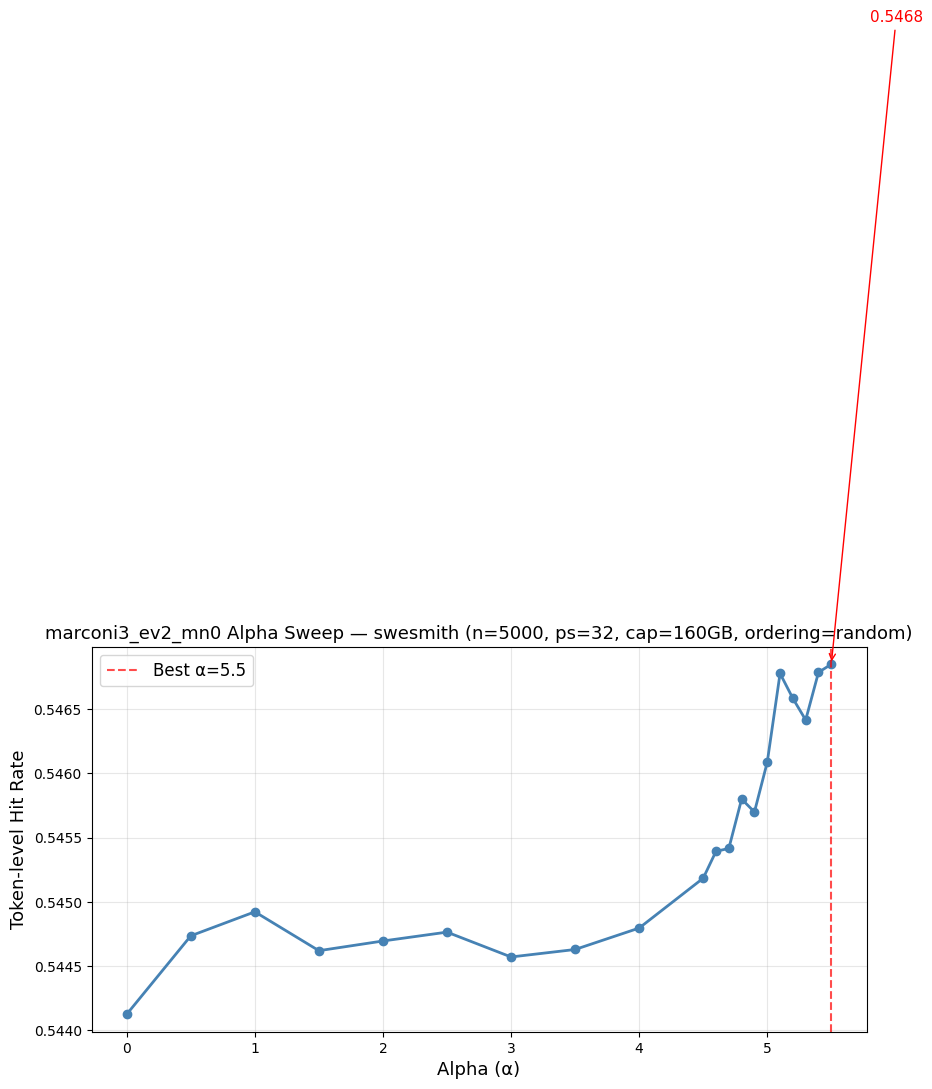


Optimal alpha = 5.5, token hit rate = 0.5468
Saved to marconi3_ev2_mn0_alpha_sweep.png


In [ ]:
import matplotlib.pyplot as plt

sorted_alphas = sorted(all_results.keys())
hrs = [all_results[a] for a in sorted_alphas]

mn_tag = "mn1" if USE_MID_CHAIN_CHECKPOINT else "mn0"
strategy_label = f"marconi3_{EVICT_MODE}_{mn_tag}"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_alphas, hrs, "o-", color="steelblue", markersize=6, linewidth=2)
ax.axvline(best_alpha, color="red", linestyle="--", alpha=0.7, label=f"Best α={best_alpha:.1f}")
ax.set_xlabel("Alpha (α)", fontsize=13)
ax.set_ylabel("Token-level Hit Rate", fontsize=13)
ax.set_title(
    f"{strategy_label} Alpha Sweep — {DATASET} (n={MAX_REQUESTS}, ps={PAGE_SIZE}, "
    f"cap={CAPACITY_SPEC}GB, ordering={ORDERING})",
    fontsize=13,
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Annotate best point
ax.annotate(
    f"{all_results[best_alpha]:.4f}",
    xy=(best_alpha, all_results[best_alpha]),
    xytext=(best_alpha + 0.3, all_results[best_alpha] + 0.005),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11, color="red",
)

plt.tight_layout()
out_name = f"marconi3_{EVICT_MODE}_{mn_tag}_alpha_sweep.png"
# plt.savefig(out_name, dpi=150)
plt.show()
print(f"\nOptimal alpha = {best_alpha:.1f}, token hit rate = {all_results[best_alpha]:.4f}")
print(f"Saved to {out_name}")